In [1]:
import sys
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F

# still do preprocessing in scipy
import scipy.sparse as sp

from importlib import reload

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/splicing-VAE')
import VAE_model
reload(VAE_model)

import matplotlib.pyplot as plt

In [2]:
# review https://sebastiancallh.github.io/post/vae-anatomy/

In [3]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import Leaflet_load_cluster_data_03 as llc 

### Settings and Load data

In [4]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [5]:
device

device(type='cuda')

In [6]:
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte'] #ignoring Bergmann_glial_cell since very few cells

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, celltypes=cell_types, remove_singletons=True, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_brain_pericyte', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage', 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']
Removing singletons ...
Number of junctions before removing singletons:  16190
Number of junctions after removing singletons:  16187
The number of unique cell types in the data is:  8
The number of unique cells in the data is:  7816
The number of unique junctions in the data is:  16188
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
The number of junctions in the data is:  15926
The number of cells in the data is:  7816
The number of cell types in the data

In [7]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7816
7816


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/Leaflet_load_cluster_data_03.py:45: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [8]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

### Get ready for model training 

In [9]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [10]:
# set up sparse tensor for junction counts 
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)

# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)

# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [11]:
# set up sparse tensor for cluster counts
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [12]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [13]:
# check if train_loader is on cuda
torch.cuda.is_available()

True

In [14]:
# Example usage:
junction_tensor, intron_tensor = y_tensor, total_counts_tensor

In [15]:
total_counts_tensor

tensor(indices=tensor([[    0,     0,     0,  ...,  7815,  7815,  7815],
                       [    0,     1,     2,  ..., 15886, 15900, 15918]]),
       values=tensor([21., 21., 16.,  ..., 31., 29., 31.]),
       size=(7816, 15926), nnz=10545293, layout=torch.sparse_coo)

In [16]:
# input --> junction usage ratios (PSI)
# output --> junction counts via inferred PSI and total counts

In [17]:
reload(VAE_model)
from VAE_model import *

In [42]:
# Configuration
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
BATCH_SIZE = 512
USE_CUDA = torch.cuda.is_available()
print(USE_CUDA)

INPUT_DIM = junction_tensor.shape[1]
HIDDEN_DIMS = [128, 64, 32]  # Example dimensions, adjust as needed
Z_DIM = 20
OUTPUT_DIM = INPUT_DIM  # Assuming output dimension matches input
perc_train = 0.7

True


In [43]:
train_loader, test_loader, full_dat = setup_data_loaders(junction_tensor, intron_tensor, BATCH_SIZE, USE_CUDA, perc_train)

model = VAE(INPUT_DIM, HIDDEN_DIMS, Z_DIM, OUTPUT_DIM)
model.train()

optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

Percentage of data used for training:  0.7


In [44]:
model

VAE(
  (encoder): Encoder(
    (body): Sequential(
      (0): Linear(in_features=15926, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=32, bias=True)
      (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
    )
    (linear_means): Linear(in_features=32, out_features=20, bias=True)
    (linear_log_var): Linear(in_features=32, out_features=20, bias=True)
  )
  (decoder): Decoder(
    (body): Sequential(
      (0): Linear(in_features=20, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momen

In [45]:
# best validation loss 
best_val_loss = float('inf')
max_patience = 5
best_epoch = 0
train_losses = []
val_losses = []

# Training Loop
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}")
    avg_train_loss = train(model, train_loader, optimizer, epoch)
    avg_val_loss = evaluate(model, test_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        patience = max_patience
    else:
        patience -= 1
        if patience == 0:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 1


====> Epoch: 1 Average training loss: 1.3122
====> Evaluation set average loss: 0.2075
Epoch 2
====> Epoch: 2 Average training loss: 0.3681
====> Evaluation set average loss: 0.1015
Epoch 3
====> Epoch: 3 Average training loss: 0.1829
====> Evaluation set average loss: 0.0639
Epoch 4
====> Epoch: 4 Average training loss: 0.1342
====> Evaluation set average loss: 0.0450
Epoch 5
====> Epoch: 5 Average training loss: 0.1085
====> Evaluation set average loss: 0.0353
Epoch 6
====> Epoch: 6 Average training loss: 0.0898
====> Evaluation set average loss: 0.0290
Epoch 7
====> Epoch: 7 Average training loss: 0.0743
====> Evaluation set average loss: 0.0243
Epoch 8
====> Epoch: 8 Average training loss: 0.0631
====> Evaluation set average loss: 0.0206
Epoch 9
====> Epoch: 9 Average training loss: 0.0527
====> Evaluation set average loss: 0.0173
Epoch 10
====> Epoch: 10 Average training loss: 0.0469
====> Evaluation set average loss: 0.0148
Epoch 11
====> Epoch: 11 Average training loss: 0.0394
=

In [46]:
# find min values in val_losses list 
min_val_loss = min(val_losses)
min_train_loss = min(train_losses)
print(f"Min validation loss: {min_val_loss}")
print(f"Min training loss: {min_train_loss}")

Min validation loss: 0.004142021878695945
Min training loss: 0.004085914153020793


In [47]:
# why is it when i increase latent space z dim, the validation loss is smaller than training loss?
# if i keep it at 20, the training loss is smaller than validation loss which is expected

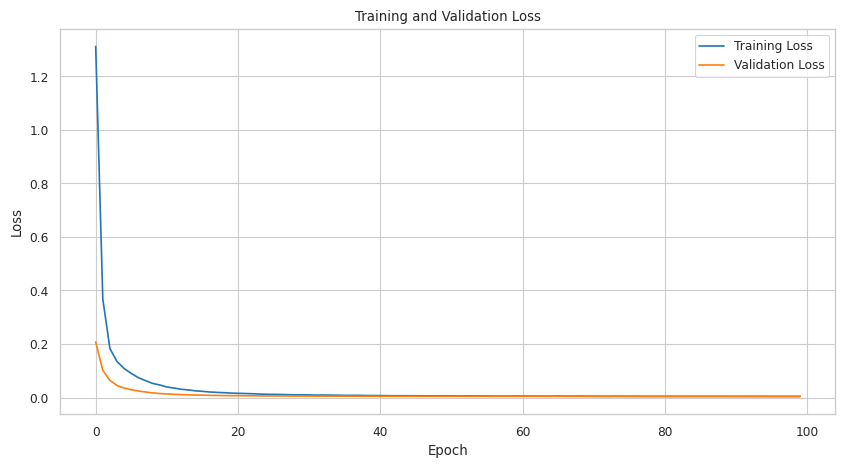

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
reload(VAE_model)
from VAE_model import *

### Obtain Z latent space 

In [50]:
model.eval()  # Set the model to evaluation mode
latent_variables = []
with torch.no_grad():
    for data in full_dat:
        inputs = data['proportions'].to(device)  # Ensure data is on the correct device
        z = model.extract_latent_variables(inputs, apply_noise=False)  # Apply_noise=False to get the mean of the latent space
        latent_variables.append(z.cpu().numpy())  # Move z to CPU and convert to numpy

latent_variables = np.concatenate(latent_variables, axis=0)

Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False


In [51]:
import umap

reducer = umap.UMAP(random_state=42)
umap_embedding = reducer.fit_transform(latent_variables)

In [52]:
import pandas as pd 
latent_variables_df = pd.DataFrame(latent_variables)
latent_variables_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.002940,-0.000671,0.004421,-0.004371,0.001578,-0.000217,0.000180,-0.002119,-0.000238,-0.003350,-0.001618,0.003033,-0.000683,0.002175,-0.000941,-0.001499,0.001382,0.003889,0.005567,0.001985
1,0.001771,-0.000107,0.004750,-0.000217,0.001200,-0.002957,-0.000459,-0.001089,0.000708,-0.003994,-0.001033,0.006092,-0.001709,0.000389,-0.000791,-0.000478,0.000855,0.002917,0.003513,-0.000614
2,0.000637,-0.000889,0.003955,-0.003020,-0.000714,-0.004078,0.001701,-0.001108,-0.001491,-0.004497,-0.000380,0.003414,-0.001363,-0.002141,0.000345,0.001014,0.000372,0.002586,0.001164,0.001158
3,-0.002547,-0.003513,0.001723,-0.003749,-0.001256,-0.002067,0.003784,0.001853,-0.001982,-0.007022,0.000213,0.003269,-0.000901,-0.001162,-0.000180,-0.000706,0.000987,0.007417,0.000308,0.000167
4,0.000196,0.000710,0.003409,-0.000586,0.001225,0.000006,0.000226,-0.003215,0.000482,-0.003371,-0.001000,0.004004,-0.001594,0.001949,-0.000865,-0.001650,0.000047,0.002658,0.001941,0.000252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7811,0.001208,-0.000950,0.002484,0.000269,-0.000302,-0.000047,0.000338,-0.003022,-0.001373,-0.001704,-0.000058,0.000366,0.001794,-0.001193,-0.001440,0.000404,-0.000569,0.000822,0.001174,0.002314
7812,0.000185,-0.000502,0.001363,0.001421,-0.000457,0.001179,0.000562,-0.003339,-0.002102,-0.000103,-0.000006,0.000846,0.000884,-0.001316,-0.001966,0.000592,-0.000772,0.000573,-0.001228,0.001767
7813,0.001582,-0.001798,0.002576,-0.000461,-0.000423,-0.000040,-0.000019,-0.002410,-0.001674,-0.003220,0.001074,0.000148,0.001471,-0.001907,-0.000493,0.000783,0.000348,0.001015,0.000827,0.001259
7814,-0.003046,0.002490,0.001229,0.002459,0.001429,0.001606,-0.001474,-0.003965,0.001362,0.002645,-0.001523,0.002220,0.000955,0.001297,-0.001028,-0.002507,-0.001234,-0.000243,-0.002859,0.000961


In [53]:
umap_embedding_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'])
umap_embedding_df["cell_type"] = cell_ids_conversion["cell_type"].values
umap_embedding_df.head()

,UMAP1,UMAP2,cell_type
0,-4.273239,2.661285,Brain_Non-Myeloid_brain_pericyte
1,-3.634128,3.217259,Brain_Non-Myeloid_brain_pericyte
2,-1.289503,11.746583,Brain_Non-Myeloid_brain_pericyte
3,-2.334272,12.195829,Brain_Non-Myeloid_brain_pericyte
4,-3.606242,2.834616,Brain_Non-Myeloid_brain_pericyte


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

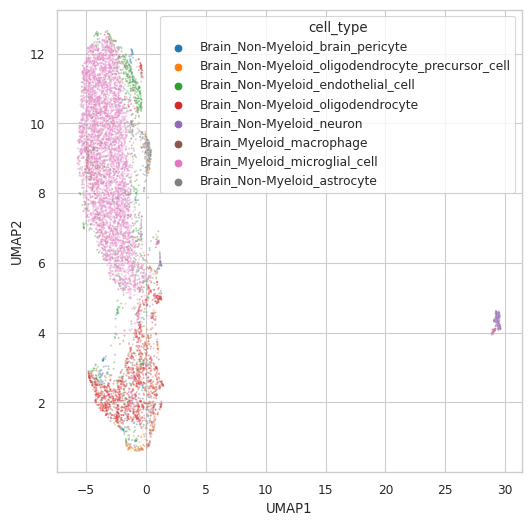

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.scatterplot(data=umap_embedding_df, x='UMAP1', y='UMAP2', hue='cell_type', palette='tab10', s=2, alpha=0.4)

In [55]:
# calcualte silhouette score
from sklearn.metrics import silhouette_score
cell_types = cell_ids_conversion["cell_type"].values
silhouette_score(umap_embedding, cell_types)

0.012610335

In [56]:
# calcualte Davies-Bouldin Index
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(umap_embedding, cell_types)

10.59903348141585

In [57]:
model

VAE(
  (encoder): Encoder(
    (body): Sequential(
      (0): Linear(in_features=15926, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=32, bias=True)
      (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
    )
    (linear_means): Linear(in_features=32, out_features=20, bias=True)
    (linear_log_var): Linear(in_features=32, out_features=20, bias=True)
  )
  (decoder): Decoder(
    (body): Sequential(
      (0): Linear(in_features=20, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momen

In [58]:
latent_variables

array([[ 0.00293983, -0.00067075,  0.00442114, ...,  0.00388902,
         0.00556652,  0.00198503],
       [ 0.00177118, -0.00010656,  0.00474954, ...,  0.00291723,
         0.0035131 , -0.00061443],
       [ 0.00063716, -0.00088885,  0.00395453, ...,  0.00258603,
         0.00116366,  0.00115842],
       ...,
       [ 0.00158228, -0.0017983 ,  0.00257647, ...,  0.00101516,
         0.00082704,  0.00125881],
       [-0.00304633,  0.0024897 ,  0.00122894, ..., -0.00024349,
        -0.00285894,  0.00096128],
       [ 0.00055219, -0.00181715,  0.00217482, ...,  0.00099714,
        -0.00027837,  0.00210537]], dtype=float32)

### Evaluate latent variables 

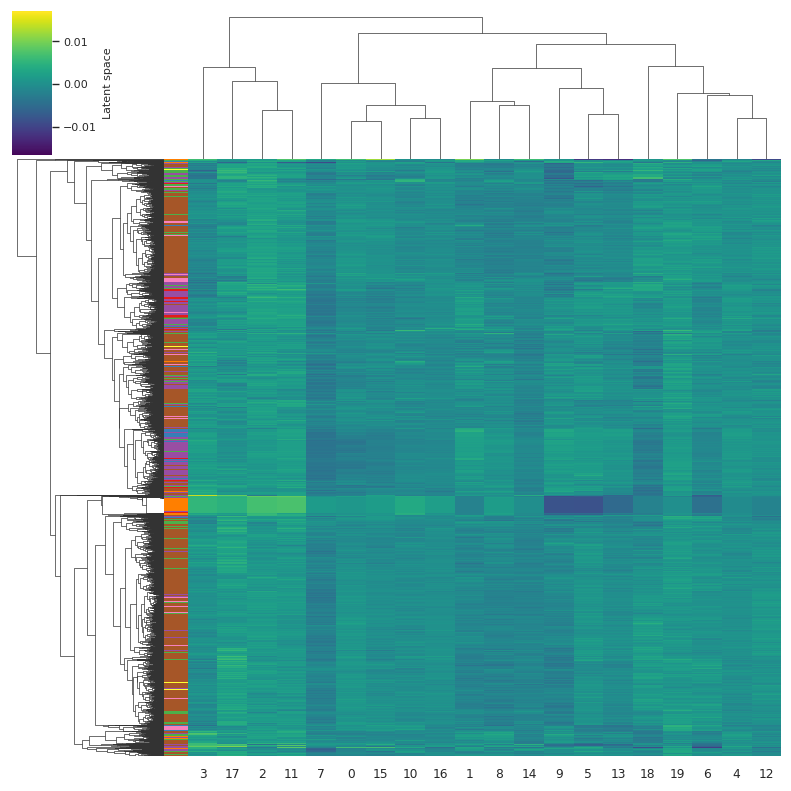

In [59]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=latent_variables,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Latent space'} 
    )
cluster.cax.set_ylabel('Latent space', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [60]:
Z_DIM

20

In [61]:
# for each cell type, get the average factor contribution
cell_type_contribs = {}
for cell_type in unique_cell_types:
    # get indices of cells of this cell type
    cell_type_indices = cell_ids_conversion[cell_ids_conversion["cell_type"] == cell_type].cell_id_index
    # get average factor contribution for these cells
    cell_type_contribs[cell_type] = latent_variables[cell_type_indices].mean(axis=0)

# make a dataframe

cell_type_contribs_df = pd.DataFrame(cell_type_contribs)
cell_type_contribs_df = cell_type_contribs_df.T
K = Z_DIM
cell_type_contribs_df.columns = ["Factor " + str(i) for i in range(K)]

cell_type_contribs_df

,Factor 0,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15,Factor 16,Factor 17,Factor 18,Factor 19
Brain_Non-Myeloid_brain_pericyte,-0.000165,0.000729,0.003100,-0.000140,0.000814,-0.000999,-0.000173,-0.002134,0.000537,-0.001492,-0.000198,0.003076,-0.001009,0.000408,-0.000697,-0.000944,0.000159,0.001542,0.000177,0.001083
Brain_Non-Myeloid_oligodendrocyte_precursor_cell,-0.001393,0.001907,0.001475,0.000939,0.000698,0.000189,-0.000372,-0.002730,0.000168,0.001095,-0.000348,0.001831,-0.000476,0.000409,-0.000972,-0.001084,-0.000756,0.000629,-0.001653,0.001648
Brain_Non-Myeloid_endothelial_cell,-0.000391,-0.000040,0.001476,-0.000051,0.000128,-0.000228,0.000209,-0.001436,-0.000099,-0.001503,-0.000491,0.001997,-0.000204,-0.000615,-0.000797,-0.000501,-0.000081,0.002407,-0.000738,0.001256
Brain_Non-Myeloid_oligodendrocyte,-0.001244,0.000725,0.001988,0.000727,0.000603,0.000761,-0.000938,-0.002838,-0.000309,-0.000311,-0.000502,0.001969,0.000150,0.000422,-0.000821,-0.001352,-0.000374,0.001587,-0.000762,0.001403
Brain_Non-Myeloid_neuron,0.000325,-0.001088,0.005315,0.003991,-0.000334,-0.006122,-0.002814,0.000443,0.001619,-0.005583,0.002685,0.004942,-0.001498,-0.003760,-0.000506,0.000959,0.001037,0.003325,-0.002162,0.000209
Brain_Myeloid_macrophage,0.000450,-0.001635,0.001634,-0.000618,-0.000413,-0.000263,0.001097,-0.001377,-0.001606,-0.002220,-0.000399,0.001438,0.000233,-0.000972,-0.001298,0.000130,-0.000020,0.002649,0.000582,0.001256
Brain_Myeloid_microglial_cell,0.000343,-0.001070,0.001682,0.000365,0.000093,0.000293,0.000592,-0.001740,-0.001241,-0.000941,-0.000564,0.001207,0.000605,-0.000546,-0.001652,-0.000237,-0.000336,0.001633,0.000358,0.001357
Brain_Non-Myeloid_astrocyte,0.000367,-0.000613,0.001797,0.000050,-0.000083,-0.000800,0.000619,-0.002117,-0.000784,-0.000099,0.000486,0.001046,0.000004,-0.001313,-0.001151,0.000197,-0.000443,0.000467,-0.000468,0.002268


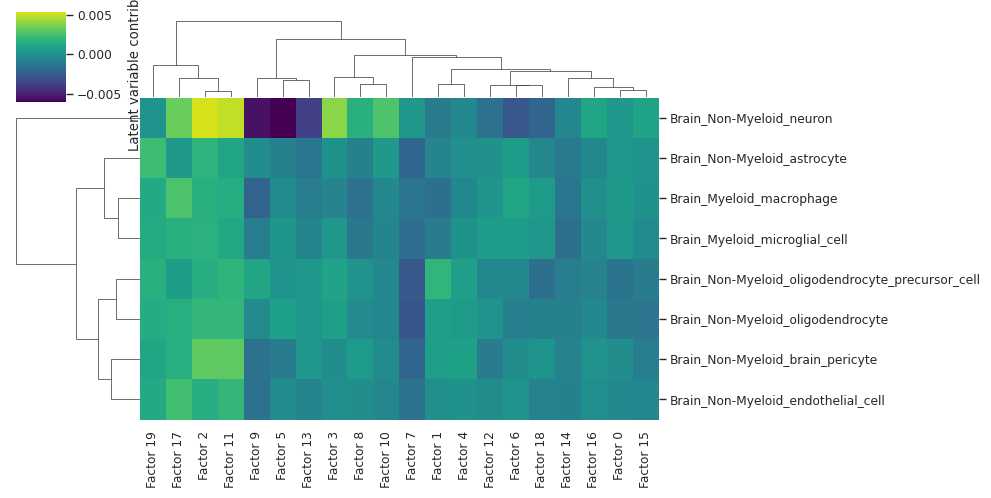

In [65]:
# plot clustermap 
sns.set_style("whitegrid")
sns.set_context("paper")
cluster = sns.clustermap(
    data=cell_type_contribs_df,
    method='complete',
    cmap="viridis",
    annot=False,
    # make font size smaller
    annot_kws={"size": 8},
    yticklabels=True,
    figsize=(10, 5),
    center=0,
    cbar_kws={'label': 'Latent variable contribution'} 
    )